<a href="https://colab.research.google.com/github/manuelcorrea212/Fisica-Computacional/blob/main/Taller_1_de_Fisica_Computacional_Manuel_Correa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Diseñe un programa en Fortran que calcule la altura máxima de un proyectil, conociendo el ángulo respecto a la horizontal y la rapidez inicial.
Su reporte debe contener el diagrama de flujo y/o pseudocodigo del programa que va a realizar.

Fórmula:
 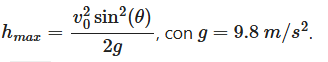

Recuerde: sin espera el ángulo en radianes (sección 7) — convierta antes de usarlo.
Variables sugeridas: v0, angulo_grados, angulo_rad, g, h_max (todas real).
Celda de verificación: al final del programa, agregue un bloque que compare h_max contra 2-3 casos de referencia conocidos e imprima PASS/FAIL para cada uno:
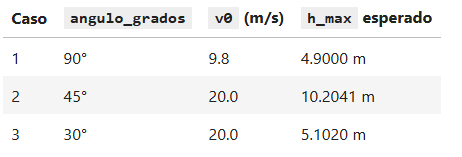

In [ ]:
%%writefile altura_maxima.f90
program altura_max
implicit none

! Diccionario de datos: constantes
real, parameter :: g = 9.8
real, parameter :: pi = 3.14159265

! Diccionario de datos: variables
real :: v0
real :: angulo_grados
real :: angulo_rad
real :: h_max

! Variables para la celda de verificacion
real :: tol = 1.0e-3
real :: h_exp1, h_exp2, h_exp3
real :: h_calc1, h_calc2, h_calc3

! Argumentos de línea de comandos para v0 y angulo_grados
integer :: i, n_args
character(len=256) :: arg_str

n_args = command_argument_count()

if (n_args == 2) then
    call get_command_argument(1, arg_str)
    read(arg_str,*) v0
    call get_command_argument(2, arg_str)
    read(arg_str,*) angulo_grados
else if (n_args == 0) then
    ! Entrada de datos interactiva si no se proporcionan argumentos
    print *, "Ingrese la rapidez inicial v0 (m/s):"
    read *, v0
    print *, "Ingrese el angulo en grados:"
    read *, angulo_grados
else
    print *, "Uso: ./altura_maxima [v0] [angulo_grados]"
    stop
end if

! Eco de entradas
print *, "Eco de entradas"
print '(A, F6.2, A)', "Rapidez inicial (v0): ", v0, " m/s"
print *, "Angulo ingresado: ", angulo_grados, " grados"

! Calculos:
angulo_rad = angulo_grados * (pi / 180.0)
h_max = (v0**2 * (sin(angulo_rad))**2) / (2.0 * g)
print *, "Altura maxima calculada (h_max): ", h_max, " m"
print *

! Casos

! Caso 1 Angulo= 90 V0 = 9.8 h_max Esperado = 4.9000 M
h_exp1 = 4.9000
h_calc1 = ((9.8**2) * (sin(90.0 * pi / 180.0))**2) / (2.0 * g)
if (abs(h_calc1 - h_exp1) < tol) then
    print *, "Caso 1 (90 deg, 9.8 m/s): PASS"
else
    print *, "Caso 1 (90 deg, 9.8 m/s): FAIL"
end if

! Caso 2 Angulo= 45 V0 = 20 h_max Esperado = 10.2041 M
h_exp2 = 10.2041
h_calc2 = ((20.0**2) * (sin(45.0 * pi / 180.0))**2) / (2.0 * g)
if (abs(h_calc2 - h_exp2) < tol) then
    print *, "Caso 2 (45 deg, 20.0 m/s): PASS"
else
    print *, "Caso 2 (45 deg, 20.0m/s): FAIL"
end if

! Caso 3 Angulo= 30 V0 = 20 h_max Esperado = 5.1020
h_exp3 = 5.1020
h_calc3 = ((20.0**2) * (sin(30.0 * pi / 180.0))**2) / (2.0 * g)
if (abs(h_calc3 - h_exp3) < tol) then
    print *, "Caso 3 (30 deg, 20.0 m/s): PASS"
else
    print *, "Caso 3 (30 deg, 20.0 m/s): FAIL"
end if

end program altura_max

# EL codigo se me dificulto ya que nunca habia trabajado con fortran, primero use comandos como # para escribir en vez de !,ademas de elif y no else if, esto provoco fallos en la codificacion, ademas no te que cuando ponia valores siempre terminaban con decimales que yo no ponia, sin saber porque, no tenia idea de que este programa corre a 32bits y que le es mas sencillo trabajar asi, despues el codigo no me codigicaba, tuve que pedirle ayuda la IA, ya que no tenia idea del porque.
# Este programa tiene como objetivo calcular la altura maxima, dada la rapidez inicial y el angulo de lanzamiento. Ademas tiene una tabla de comparacion para ver el fucionamiento del programa, El código comienza configurando la precisión numérica mediante un identificador dp definido con selected_real_kind(15, 307). Esta declaración asigna variables de precisión doble (64 bits) a constantes como la aceleración de la gravedad (g = 9.8\text{ m/s}^2) y el valor de \pi, lo que evita imprecisiones en los decimales al realizar las operaciones aritméticas, despues el diccionario de variales da los espacios de memoria para registrar  la velocidad inicial, el ángulo en grados, el valor de pi,  lo que evita imprecisiones en los decimales al realizar las operaciones aritméticas, la conversión del ángulo a radianes y la variable receptora de la altura máxima calculada.
# Posteriormente el programa gestiona  la entrada de datos mediante la función command_argument_count(). Si el script detecta que el usuario envió dos parámetros desde la línea de comandos en la terminal de Colab. lee y asigna directamente estos valores utilizando get_command_argument(). En caso de ejecutarse sin argumentos, activa una entrada interactiva básica mediante mensajes print * y lecturas read *. Tras capturar las entradas, despliega un eco de datos formateado en pantalla para confirmar la información procesada.
# En el procesamiento matematico el programa convierte el ángulo ingresado de grados a radianes multiplicándolo por el factor \pi / 180.0, un paso indispensable ya que la función trigonométrica sin en Fortran requiere sus argumentos expresados en radianes. Una vez realizada la conversión, aplica la ecuación de la física parabólica h_{max} = \frac{v_0^2 \cdot \sin^2(\theta)}{2g} e imprime el resultado final en metros con un formato explícito de decimales. Finalmente, el código ejecuta una celda de verificación compuesta por tres casos de prueba teóricos predeterminados. Cada caso evalúa la fórmula matemática con valores conocidos (90^\circ a 9.8\text{ m/s}, 45^\circ a 20.0\text{ m/s} y 30^\circ a 20.0\text{ m/s}) y compara el valor calculado contra el esperado utilizando una tolerancia flotante tol = 1.0e-3, imprimiendo el estado PASS o FAIL para validar el correcto funcionamiento físico y lógico del programa.

Overwriting altura_maxima.f90


In [ ]:
!gfortran altura_maxima.f90 -o altura_maxima && ./altura_maxima

 Ingrese la rapidez inicial v0 (m/s):
